# House M.D. NLP Veri Seti Hazirlama, Analiz ve Modelleme

Bu notebook `DATA/Last_HouseMD_DataSet.csv` dosyasini kullanarak House M.D. repliklerinden tani siniflandirma modeli olusturur. Calisma uc ana asamaya ayrilmistir:

1. **House MD veri setinin hazirlanmasi**: veri okuma, kolon kalitesi, eksik/bozuk deger ve hedef sinif analizi.
2. **On isleme ve ozellik secimi**: metin temizleme, medical entity ayrisitirma, ayni anlama gelen tani etiketlerini birlestirme, sinif dengesizligi analizi ve TF-IDF ozellikleri.
3. **Modelleme**: dengesiz veri icin agirlikli modeller, oversampling ve hafif data augmentation stratejilerini karsilastirma.

Varsayilan hedef kolon `correct_prediction` kolonudur. Bu kolon tanilari temsil ettigi icin problem cok sinifli metin siniflandirma olarak ele alinir.

## Yapilacak adimlar

1. Paketleri yukle ve veri setini oku.
2. Eksik deger, tekrar, metin uzunlugu ve ham sinif dagilimini incele.
3. Metinleri, hedef etiketleri ve `medical_entities` alanini temizle.
4. Ayni anlama gelen veya yazim farki tasiyan tani etiketlerini tek canonical sinifta birlestir.
5. Bos/gecersiz ve cok seyrek siniflari filtrele.
6. Sinif dengesizligini grafiklerle analiz et; ozellikle baskin `n?rosistiserkozis` sinifinin etkisini goster.
7. Kelime n-gram ve karakter n-gram TF-IDF ozellikleri uret.
8. Class weight, oversampling ve data augmentation kullanan modelleri karsilastir.
9. En iyi modeli test setinde `macro_f1`, balanced accuracy ve weighted F1 ile raporla.
10. Hata analizi yap ve modeli notebook icinde bellekte kullan.

In [1]:
# Eksik paketleri otomatik kurar.
# Internet kapaliysa bu hucre hata verebilir; bu durumda paketleri manuel kurmak gerekir.
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

missing = [pip_name for import_name, pip_name in required_packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Kurulacak eksik paketler:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Gerekli paketler zaten kurulu.")

Gerekli paketler zaten kurulu.


In [ ]:
import json
import re
import unicodedata
import warnings
from pathlib import Path
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", font_scale=0.9)

In [ ]:
DATA_PATH = Path("DATA") / "Last_HouseMD_DataSet.csv"
MODEL_PATH = Path("models") / "best_housemd_diagnosis_model.joblib"
TARGET_COLUMN = "correct_prediction"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_CLASS_COUNT = 20
CV_FOLDS = 3
SELECTION_METRIC = "macro_f1"
BALANCED_TRAIN_CLASS_SIZE = 60

print("Data file:", DATA_PATH.resolve())
print("Target column:", TARGET_COLUMN)
print("Selection metric:", SELECTION_METRIC)
print("Required balanced train class size:", BALANCED_TRAIN_CLASS_SIZE)
print("Deployment model path:", MODEL_PATH.resolve())

Data file: C:\Users\moham\Desktop\NLP_Project\DATA\Last_HouseMD_DataSet.csv
Target column: correct_prediction
Selection metric: macro_f1
Required balanced train class size: 60
Deployment model path: C:\Users\moham\Desktop\NLP_Project\models\best_housemd_diagnosis_model.joblib


## 1. Veri setini okuma

CSV dosyasi `;` ile ayrilmis. Butun kolonlari once metin olarak okuyoruz; boylece karisik tipli veya bozuk alanlarda veri kaybi olmaz.

In [ ]:
df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
    dtype=str,
    on_bad_lines="warn",
).fillna("")

for column in df_raw.columns:
    df_raw[column] = df_raw[column].astype(str).str.strip()

raw_row_count = len(df_raw)
blank_row_mask = df_raw.apply(lambda row: all(str(value).strip() == "" for value in row), axis=1)
blank_row_count = int(blank_row_mask.sum())
df_raw = df_raw.loc[~blank_row_mask].reset_index(drop=True)

print("Raw rows read:", raw_row_count)
print("Fully blank rows removed:", blank_row_count)
print("Rows after blank-row cleanup:", df_raw.shape[0])
print("Column count:", df_raw.shape[1])
display(df_raw.head())

Raw rows read: 7282
Fully blank rows removed: 0
Rows after blank-row cleanup: 7282
Column count: 16


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ""Symptom""}]"
3,1,1,House,,,,,şaka,hipotez,1,alaycı,beyin,nörosistiserkozis,,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"
4,1,1,Wilson,,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Onun yaşında beyin tümörü olması pek olası değil.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"


## 2. Ilk veri kalitesi analizi

Bu bolumde eksik degerler, benzersiz deger sayilari, tekrar eden metinler ve hedef etiket dagilimi incelenir. Bu adim model sonucunu yorumlamak icin gereklidir.

In [5]:
quality_report = pd.DataFrame({
    "column": df_raw.columns,
    "missing_count": [(df_raw[col].str.strip() == "").sum() for col in df_raw.columns],
    "missing_ratio": [round((df_raw[col].str.strip() == "").mean(), 4) for col in df_raw.columns],
    "unique_count": [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
}).sort_values("missing_ratio", ascending=False)

display(quality_report)

,column,missing_count,missing_ratio,unique_count
13,model_prediction,5874,0.8066,311
6,Procedure,5074,0.6968,613
5,Drug,5051,0.6936,573
4,Test,4614,0.6336,885
3,Symptom,2637,0.3621,2685
11,Organ,2164,0.2972,759
12,correct_prediction,1470,0.2019,655
7,Intent,200,0.0275,218
15,medical_entities,139,0.0191,5760
10,Emotion,2,0.0003,248


Bos text satiri: 1
Tam ayni text tekrar sayisi: 122
Ortalama kelime sayisi: 8.74
Medyan kelime sayisi: 8.0
Maksimum kelime sayisi: 60


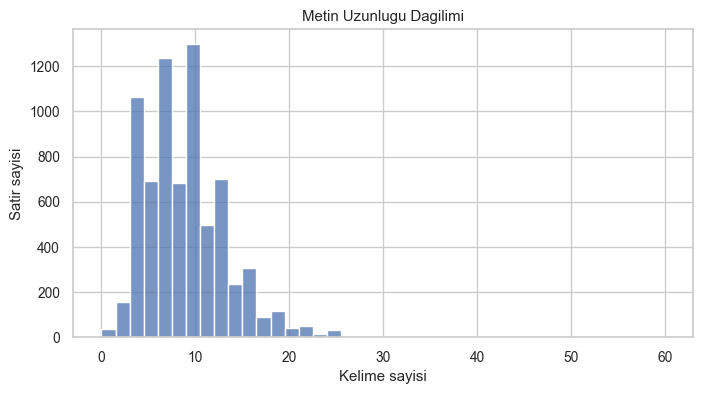

In [6]:
text_lengths = df_raw["text"].fillna("").astype(str).str.split().str.len()

print("Bos text satiri:", (df_raw["text"].str.strip() == "").sum())
print("Tam ayni text tekrar sayisi:", df_raw["text"].duplicated().sum())
print("Ortalama kelime sayisi:", round(text_lengths.mean(), 2))
print("Medyan kelime sayisi:", round(text_lengths.median(), 2))
print("Maksimum kelime sayisi:", int(text_lengths.max()))

plt.figure(figsize=(8, 4))
sns.histplot(text_lengths, bins=40)
plt.title("Metin Uzunlugu Dagilimi")
plt.xlabel("Kelime sayisi")
plt.ylabel("Satir sayisi")
plt.show()

Hedef kolon ilk 30 deger dagilimi:


,count
correct_prediction,
,1470
nörosistiserkozis,422
none,192
1,180
melanom,100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,69
Travma Sonrası Siringomyeli,65
amiloidoz,64
kimerizm,63


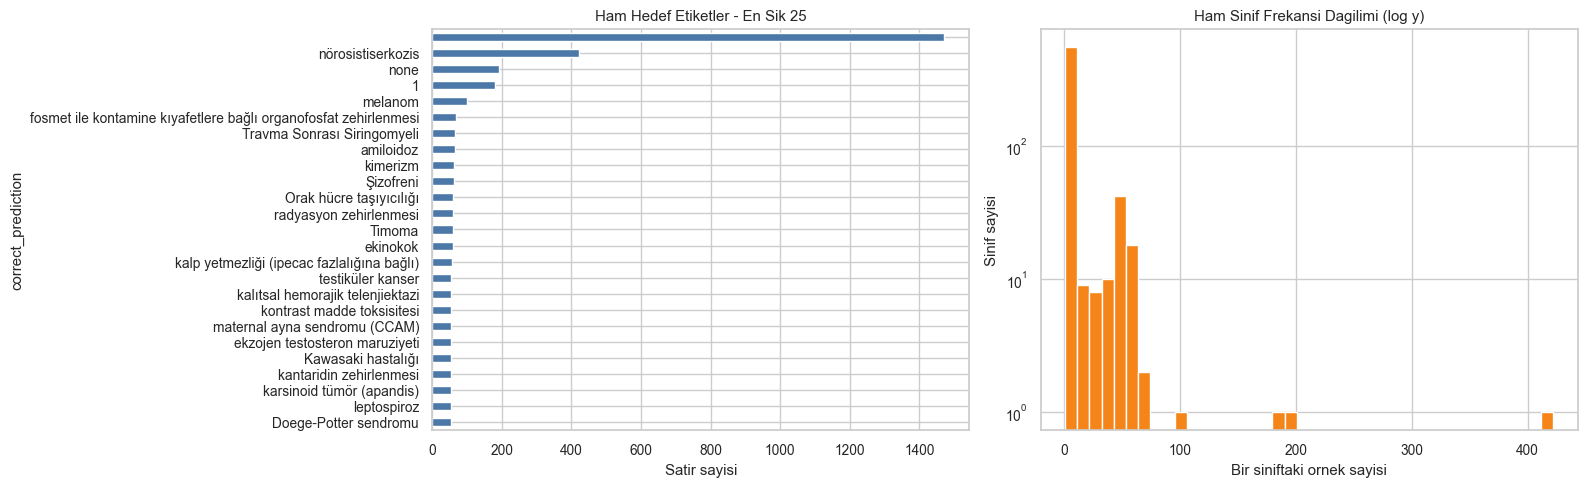

Ham hedefte bos/none/1/0 gibi gecersiz gorunen degerler modelleme oncesi filtrelenecek.


In [7]:
target_raw = df_raw[TARGET_COLUMN].fillna("").astype(str).str.strip()
raw_target_counts = target_raw.value_counts(dropna=False)

print("Hedef kolon ilk 30 deger dagilimi:")
display(raw_target_counts.head(30).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
raw_target_counts.head(25).sort_values().plot(kind="barh", ax=axes[0], color="#4c78a8")
axes[0].set_title("Ham Hedef Etiketler - En Sik 25")
axes[0].set_xlabel("Satir sayisi")
axes[0].set_ylabel(TARGET_COLUMN)

raw_target_counts[raw_target_counts.index.astype(str).str.strip() != ""].plot(
    kind="hist",
    bins=40,
    ax=axes[1],
    color="#f58518",
    logy=True,
)
axes[1].set_title("Ham Sinif Frekansi Dagilimi (log y)")
axes[1].set_xlabel("Bir siniftaki ornek sayisi")
axes[1].set_ylabel("Sinif sayisi")
plt.tight_layout()
plt.show()

print("Ham hedefte bos/none/1/0 gibi gecersiz gorunen degerler modelleme oncesi filtrelenecek.")

## 3. Temizleme ve normalizasyon

Veri setinde Turkce karakterler, buyuk/kucuk harf farklari, bos alanlar ve bozuk JSON benzeri `medical_entities` degerleri var. Fonksiyonlar bu alanlari model icin daha kararli hale getirir.

Karakter n-gram TF-IDF kullanildigi icin yazim farklari ve eksik/bozuk kelimelere karsi model daha dayanikli olur.

In [ ]:
TURKISH_CHARS = "\u00e7\u011f\u0131\u00f6\u015f\u00fc"

TR_STOPWORDS = {
    "acaba", "ama", "aslinda", "az", "bazi", "belki", "biri", "birkac", "birsey",
    "biz", "bu", "cok", "cunku", "da", "daha", "de", "defa", "diye", "eger",
    "en", "gibi", "hem", "hep", "hepsi", "her", "hic", "icin", "ile", "ise",
    "kez", "ki", "kim", "mi", "mu", "nasil", "ne", "neden", "nerede", "nereye",
    "nicin", "niye", "o", "sanki", "sey", "siz", "su", "tum", "ve", "veya",
    "ya", "yani", "ben", "sen", "onlar", "bizim", "sizin", "var", "yok",
}

INVALID_LABELS = {"", "none", "nan", "1", "0", "-"}
TEXT_FEATURE_COLUMNS = ["text", "Symptom", "Test", "Drug", "Procedure", "Organ"]
META_FEATURE_COLUMNS = ["speaker", "Intent", "diagnosis_stage", "Emotion", "Sarcasm"]
LEAKAGE_COLUMNS = ["correct_prediction", "model_prediction", "season", "episode"]

# Manually reviewed: these are spelling/expression variants of the same diagnosis.
LABEL_SYNONYM_MAP = {
    "wilson hastal\u0131\u011f\u0131 tan\u0131s\u0131": "wilson hastal\u0131\u011f\u0131",
    "ipecac fazlal\u0131\u011f\u0131na ba\u011fl\u0131": "ipecac zehirlenmesi / kalp yetmezli\u011fi",
    "kalp yetmezli\u011fi ipecac fazlal\u0131\u011f\u0131na ba\u011fl\u0131": "ipecac zehirlenmesi / kalp yetmezli\u011fi",
    "kalp yetmezli\u011fi / ipecac fazlal\u0131\u011f\u0131na ba\u011fl\u0131": "ipecac zehirlenmesi / kalp yetmezli\u011fi",
    "ipecac \u015furubu zehirlenmesi": "ipecac zehirlenmesi / kalp yetmezli\u011fi",
    "munchausen sendromu ve ipecac zehirlenmesi": "ipecac zehirlenmesi / kalp yetmezli\u011fi",
    "c\u00fczzam leprozi": "c\u00fczzam / leprozi",
    "leprozi": "c\u00fczzam / leprozi",
    "sjogren sendromu": "sj\u00f6gren sendromu",
    "fosmet ile kont m3 m82amine k\u0131yafetlere ba\u011fl\u0131 organofosfat zehirlenmesi": "fosmet ile kontamine k\u0131yafetlere ba\u011fl\u0131 organofosfat zehirlenmesi",
}


def normalize_text(value):
    """Basic text normalization that keeps Turkish medical terms intact."""
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value))
    text = text.lower().replace("\u0307", "")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(f"[^0-9a-z{TURKISH_CHARS}\s\-/+%.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_label(value):
    label = normalize_text(value)
    label = label.replace("(", " ").replace(")", " ")
    label = re.sub(r"\s*/\s*", " / ", label)
    label = re.sub(r"\s+", " ", label).strip()
    return label


def canonicalize_label(value):
    """Merge only clearly equivalent diagnosis labels."""
    label = normalize_label(value)
    if label in INVALID_LABELS:
        return label

    label = re.sub("\\btan\\u0131s\\u0131\\b", "", label).strip()
    label = re.sub(r"\s+", " ", label)

    if label in LABEL_SYNONYM_MAP:
        return LABEL_SYNONYM_MAP[label]

    if "fosmet" in label and "organofosfat" in label:
        return "fosmet ile kontamine k\u0131yafetlere ba\u011fl\u0131 organofosfat zehirlenmesi"
    if "ipecac" in label:
        return "ipecac zehirlenmesi / kalp yetmezli\u011fi"
    if label in {"sj\u00f6gren sendromu", "sjogren sendromu"}:
        return "sj\u00f6gren sendromu"
    if label in {"c\u00fczzam", "c\u00fczzam leprozi", "leprozi"}:
        return "c\u00fczzam / leprozi"

    return label


def extract_medical_entities(value):
    """Extract entity text/type tokens even when the JSON-like cell is imperfect."""
    if pd.isna(value) or not str(value).strip():
        return ""

    raw = str(value).strip().replace('\"\"', '\"')
    candidates = [raw]
    if not raw.startswith("["):
        candidates.append("[" + raw)
    if not raw.endswith("]"):
        candidates.append(raw + "]")
    if not (raw.startswith("[") and raw.endswith("]")):
        candidates.append("[" + raw.strip("[]") + "]")

    for candidate in candidates:
        try:
            parsed = json.loads(candidate)
            if isinstance(parsed, dict):
                parsed = [parsed]
            tokens = []
            if isinstance(parsed, list):
                for item in parsed:
                    if isinstance(item, dict):
                        entity_text = normalize_text(item.get("text", ""))
                        entity_type = normalize_text(item.get("type", "")).replace(" ", "_")
                        if entity_text:
                            tokens.append(entity_text)
                        if entity_type:
                            tokens.append(f"entity_{entity_type}")
            if tokens:
                return " ".join(tokens)
        except Exception:
            pass

    entity_texts = re.findall(r'"text"\s*:\s*"([^"]+)"', raw)
    entity_types = re.findall(r'"type"\s*:\s*"([^"]+)"', raw)
    tokens = [normalize_text(x) for x in entity_texts]
    tokens += ["entity_" + normalize_text(x).replace(" ", "_") for x in entity_types]
    return " ".join([token for token in tokens if token])


def build_model_text(row):
    parts = []

    for col in TEXT_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(value)

    for col in META_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(f"{col.lower()}_{value.replace(' ', '_')}")

    entities = extract_medical_entities(row.get("medical_entities", ""))
    if entities:
        parts.append(entities)

    return " ".join(parts)

## 4. Modelleme veri setini hazirlama

Hedef etiket temizlenir, bos/gecersiz etiketler cikarilir, model metni olusturulur ve cok seyrek siniflar filtrelenir.

Varsayilan `MIN_CLASS_COUNT = 20`. Bu esik, her sinifta train/test bolme icin yeterli ornek kalmasina yardim eder.

In [ ]:
df = df_raw.copy()
df["target_raw_clean"] = df[TARGET_COLUMN].apply(normalize_label)
df["target"] = df[TARGET_COLUMN].apply(canonicalize_label)
df["model_text"] = df.apply(build_model_text, axis=1)

before_rows = len(df)
before_valid_class_count = df.loc[~df["target_raw_clean"].isin(INVALID_LABELS), "target_raw_clean"].nunique()
invalid_target_mask = df["target"].isin(INVALID_LABELS)
empty_text_mask = df["model_text"].str.len().eq(0)

cleaning_audit = pd.DataFrame([
    {"step": "raw_rows_after_blank_row_cleanup", "rows": int(before_rows)},
    {"step": "removed_invalid_or_empty_target", "rows": int(invalid_target_mask.sum())},
    {"step": "removed_empty_model_text", "rows": int((~invalid_target_mask & empty_text_mask).sum())},
])

df_clean = df.loc[~invalid_target_mask & ~empty_text_mask].copy()
after_canonical_class_count = df_clean["target"].nunique()

merge_summary = (
    df_clean.groupby("target")
    .agg(
        row_count=("target", "size"),
        raw_label_count=("target_raw_clean", "nunique"),
        raw_labels=("target_raw_clean", lambda s: "; ".join(sorted(set(s))[:8])),
    )
    .reset_index()
    .sort_values(["raw_label_count", "row_count"], ascending=False)
)

target_counts = df_clean["target"].value_counts()
eligible_classes = target_counts[target_counts >= MIN_CLASS_COUNT].index
rare_class_count = int((target_counts < MIN_CLASS_COUNT).sum())
rare_row_count = int(target_counts[target_counts < MIN_CLASS_COUNT].sum())

df_model = df_clean[df_clean["target"].isin(eligible_classes)].copy()
before_dedup = len(df_model)
df_model = df_model.drop_duplicates(subset=["model_text", "target"]).reset_index(drop=True)
duplicate_rows_removed = before_dedup - len(df_model)

print("Starting rows:", before_rows)
print("Valid raw class count:", before_valid_class_count)
print("Class count after canonical merge:", after_canonical_class_count)
print("Rows after target/text cleanup:", len(df_clean))
print(f"Rare classes removed (<{MIN_CLASS_COUNT} rows):", rare_class_count, "classes /", rare_row_count, "rows")
print("Duplicate model rows removed:", duplicate_rows_removed)
print(f"Model rows after min-class filter and dedup:", len(df_model))
print("Model class count:", df_model["target"].nunique())

display(cleaning_audit)
display(merge_summary[merge_summary["raw_label_count"] > 1].head(20))
display(df_model[["season", "episode", "speaker", "text", "target_raw_clean", "target", "model_text"]].head())

Starting rows: 7282
Valid raw class count: 633
Class count after canonical merge: 625
Rows after target/text cleanup: 5415
Rare classes removed (<20 rows): 545 classes / 1001 rows
Duplicate model rows removed: 0
Model rows after min-class filter and dedup: 4414
Model class count: 80


,step,rows
0,raw_rows_after_blank_row_cleanup,7282
1,removed_invalid_or_empty_target,1867
2,removed_empty_model_text,0


,target,row_count,raw_label_count,raw_labels
250,ipecac zehirlenmesi / kalp yetmezliği,90,4,ipecac fazlalığına bağlı; ipecac şurubu zehirlenmesi; kalp yetmezliği ipecac fazlalığına bağlı; munchausen sendromu ve ipecac zehirlenmesi
599,wilson hastalığı,91,2,wilson hastalığı; wilson hastalığı tanısı
177,fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,70,2,fosmet ile kont+m3 m82amine kıyafetlere bağlı organofosfat zehirlenmesi; fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi
365,lupus,51,2,lupus; lupus tanısı
293,karaciğer yetmezliği,3,2,karaciğer yetmezliği; karaciğer yetmezliği tanısı
579,vaskülit,2,2,vaskülit; vaskülit tanısı


,season,episode,speaker,text,target_raw_clean,target,model_text
0,1,1,Wilson,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,nörosistiserkozis,nörosistiserkozis,29 yaşında bir kadın hasta ilk nöbetini bir ay önce geçirmiş. nöbet beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 nöbe...
1,1,1,Wilson,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.",nörosistiserkozis,nörosistiserkozis,konuşma yetisini kaybetmiş bebek gibi anlamsız sesler çıkarıyor. afazi beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 a...
2,1,1,Wilson,Mental durumu giderek kötüleşiyor.,nörosistiserkozis,nörosistiserkozis,mental durumu giderek kötüleşiyor. zihinsel durum bozukluğu beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 zihinsel dur...
3,1,1,House,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,nörosistiserkozis,nörosistiserkozis,beyin tümörü dediler ben olsam ben de o tanıyı sevmezdim. ölecek demenin sıkıcı bir yolu. beyin speaker_house intent_şaka diagnosis_stage_hipotez emotion_al...
4,1,1,Wilson,Onun yaşında beyin tümörü olması pek olası değil.,nörosistiserkozis,nörosistiserkozis,onun yaşında beyin tümörü olması pek olası değil. beyin speaker_wilson intent_açıklama diagnosis_stage_hipotez emotion_nötr sarcasm_0 beyin tümörü entity_di...


,target,count
0,nörosistiserkozis,422
1,melanom,100
2,wilson hastalığı,91
3,ipecac zehirlenmesi / kalp yetmezliği,90
4,fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,70
5,travma sonrası siringomyeli,65
6,amiloidoz,64
7,kimerizm,63
8,şizofreni,62
9,orak hücre taşıyıcılığı,61


Model verisi sinif min/max: 23 422
Model verisi dengesizlik orani: 18.35
En baskin sinif: nörosistiserkozis -> 422 ornek


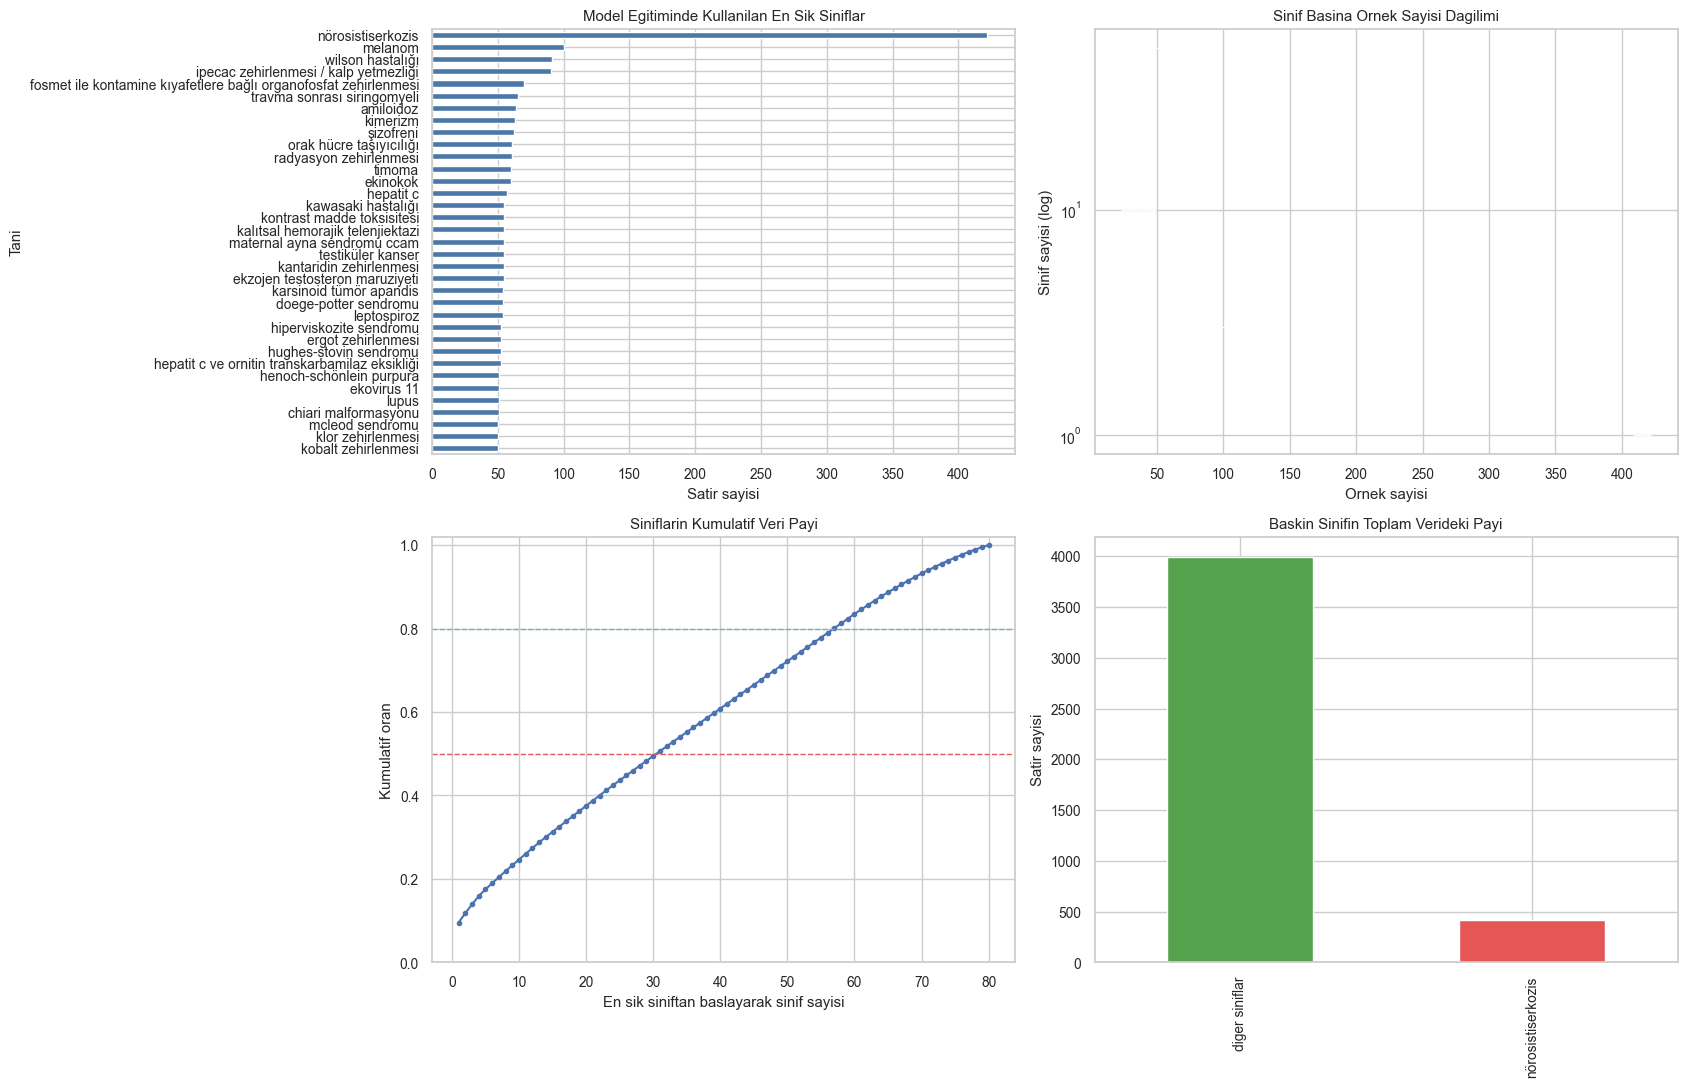

In [10]:
class_summary = df_model["target"].value_counts().rename_axis("target").reset_index(name="count")
display(class_summary.head(30))

imbalance_ratio = class_summary["count"].max() / class_summary["count"].min()
dominant_class = class_summary.iloc[0]
print("Model verisi sinif min/max:", int(class_summary["count"].min()), int(class_summary["count"].max()))
print("Model verisi dengesizlik orani:", round(imbalance_ratio, 2))
print("En baskin sinif:", dominant_class["target"], "->", int(dominant_class["count"]), "ornek")

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
class_summary.head(35).sort_values("count").plot(
    kind="barh",
    x="target",
    y="count",
    legend=False,
    ax=axes[0, 0],
    color="#4c78a8",
)
axes[0, 0].set_title("Model Egitiminde Kullanilan En Sik Siniflar")
axes[0, 0].set_xlabel("Satir sayisi")
axes[0, 0].set_ylabel("Tani")

sns.histplot(class_summary["count"], bins=30, ax=axes[0, 1], color="#f58518", log_scale=(False, True))
axes[0, 1].set_title("Sinif Basina Ornek Sayisi Dagilimi")
axes[0, 1].set_xlabel("Ornek sayisi")
axes[0, 1].set_ylabel("Sinif sayisi (log)")

sorted_counts = class_summary["count"].sort_values(ascending=False).reset_index(drop=True)
cumulative_ratio = sorted_counts.cumsum() / sorted_counts.sum()
axes[1, 0].plot(range(1, len(cumulative_ratio) + 1), cumulative_ratio, marker="o", markersize=3)
axes[1, 0].axhline(0.5, color="#e45756", linestyle="--", linewidth=1)
axes[1, 0].axhline(0.8, color="#72b7b2", linestyle="--", linewidth=1)
axes[1, 0].set_title("Siniflarin Kumulatif Veri Payi")
axes[1, 0].set_xlabel("En sik siniftan baslayarak sinif sayisi")
axes[1, 0].set_ylabel("Kumulatif oran")
axes[1, 0].set_ylim(0, 1.02)

neuro_name = "nörosistiserkozis"
focus = class_summary.copy()
focus["group"] = np.where(focus["target"] == neuro_name, neuro_name, "diger siniflar")
focus.groupby("group")["count"].sum().plot(kind="bar", ax=axes[1, 1], color=["#54a24b", "#e45756"])
axes[1, 1].set_title("Baskin Sinifin Toplam Verideki Payi")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Satir sayisi")
plt.tight_layout()
plt.show()

## 5. Train/test bolme

Stratified split kullanilir; boylece her sinifin train ve test setindeki orani mumkun oldugunca korunur.

Not: Ayni House M.D. bolumundeki satirlar ayni taniya bagli olabilir. Bu nedenle sonuc, tamamen yeni hastalik genellemesinden cok ayni veri dagilimindaki satirlari siniflandirma basarisini gosterir.

In [11]:
X = df_model["model_text"]
y = df_model["target"]
indices = df_model.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train satir:", len(X_train))
print("Test satir:", len(X_test))
print("Train sinif:", y_train.nunique())
print("Test sinif:", y_test.nunique())

Train satir: 3531
Test satir: 883
Train sinif: 80
Test sinif: 80


## 6. TF-IDF ozellikleri, zorunlu sinif dengeleme ve model adaylari

Bu projede etiketlerin esit veya birbirine cok yakin olmasi sart oldugu icin final model **yalnizca dengelenmis egitim verisi** kullanan adaylardan secilir.

Dengeleme train/validation/test ayrimindan sonra yapilir. Boylece ayni satirin kopyasi test setine sizmaz; test seti gercek veri dagilimini olcerken model egitimi her siniftan esit sayida ornek gorur.


In [12]:
def make_features(profile="mid"):
    """TF-IDF feature profiles for short medical/dialogue text."""
    if profile == "base":
        word_params = dict(ngram_range=(1, 2), min_df=2, max_df=0.95, max_features=60_000)
        char_params = dict(ngram_range=(3, 5), min_df=2, max_features=60_000)
    else:
        word_params = dict(ngram_range=(1, 3), min_df=1, max_df=0.90, max_features=120_000)
        char_params = dict(ngram_range=(2, 5), min_df=2, max_features=80_000)

    word_tfidf = TfidfVectorizer(
        lowercase=False,
        sublinear_tf=True,
        stop_words=list(TR_STOPWORDS),
        **word_params,
    )

    char_tfidf = TfidfVectorizer(
        lowercase=False,
        analyzer="char_wb",
        sublinear_tf=True,
        **char_params,
    )

    return FeatureUnion([
        ("word", word_tfidf),
        ("char", char_tfidf),
    ])


AUGMENT_SYNONYMS = {
    "n\u00f6bet": ["konv\u00fclsiyon", "atak"],
    "a\u011fr\u0131": ["sanc\u0131"],
    "ate\u015f": ["y\u00fcksek ate\u015f"],
    "kusma": ["bulant\u0131 kusma"],
    "bulant\u0131": ["mide bulant\u0131s\u0131"],
    "t\u00fcm\u00f6r": ["kitle"],
    "kanser": ["malignite"],
    "enfeksiyon": ["infeksiyon"],
    "b\u00f6brek": ["renal"],
    "karaci\u011fer": ["hepatik"],
    "kalp": ["kardiyak"],
    "beyin": ["serebral"],
    "akci\u011fer": ["pulmoner"],
    "zehirlenmesi": ["toksisitesi"],
}


def augment_text(text, rng):
    """Create a light variant for duplicated minority-class training rows."""
    tokens = str(text).split()
    if len(tokens) < 4:
        return text

    augmented = []
    changed = False
    for token in tokens:
        replacement_options = AUGMENT_SYNONYMS.get(token)
        if replacement_options and rng.random() < 0.35:
            augmented.extend(rng.choice(replacement_options).split())
            changed = True
        elif token in TR_STOPWORDS and len(tokens) > 8 and rng.random() < 0.20:
            changed = True
            continue
        else:
            augmented.append(token)

    if len(augmented) > 6 and rng.random() < 0.30:
        pos = int(rng.integers(0, len(augmented) - 1))
        augmented[pos], augmented[pos + 1] = augmented[pos + 1], augmented[pos]
        changed = True

    if not changed and len(augmented) > 6:
        drop_pos = int(rng.integers(0, len(augmented)))
        augmented = augmented[:drop_pos] + augmented[drop_pos + 1:]

    return " ".join(augmented) if len(augmented) >= 3 else text


def balance_training_data(X, y, strategy="none", random_state=RANDOM_STATE):
    """Balance only the supplied training split; validation/test data is untouched."""
    data = pd.DataFrame({"text": list(X), "target": list(y)})
    if strategy in (None, "none"):
        return data["text"], data["target"]

    counts = data["target"].value_counts()
    rng = np.random.default_rng(random_state)

    if strategy == "median_oversample":
        target_size = int(np.ceil(counts.median()))
        exact_equal = False
    elif strategy == "balanced_equal_60":
        target_size = BALANCED_TRAIN_CLASS_SIZE
        exact_equal = True
    elif strategy == "balanced_equal_80":
        target_size = 80
        exact_equal = True
    else:
        raise ValueError(f"Unknown balancing strategy: {strategy}")

    pieces = []
    for _, group in data.groupby("target", sort=False):
        n_rows = target_size if exact_equal else max(len(group), target_size)
        replace = len(group) < n_rows
        sampled_idx = rng.choice(group.index.to_numpy(), size=n_rows, replace=replace)
        sampled = data.loc[sampled_idx].copy().reset_index(drop=True)

        if replace and strategy.startswith("balanced_equal"):
            sampled.loc[len(group):, "text"] = sampled.loc[len(group):, "text"].apply(lambda value: augment_text(value, rng))

        pieces.append(sampled)

    balanced = pd.concat(pieces).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced["text"], balanced["target"]


def make_pipeline(feature_profile, clf):
    return Pipeline([
        ("features", make_features(feature_profile)),
        ("clf", clone(clf)),
    ])


def fit_model_spec(spec, X_fit, y_fit, random_state=RANDOM_STATE):
    X_bal, y_bal = balance_training_data(
        X_fit,
        y_fit,
        strategy=spec["resampling"],
        random_state=random_state,
    )
    model = make_pipeline(spec["features"], spec["clf"])
    model.fit(X_bal, y_bal)
    return model, len(X_bal), int(y_bal.value_counts().min()), int(y_bal.value_counts().max())


model_specs = [
    {
        "name": "Dummy Baseline",
        "features": "base",
        "resampling": "none",
        "clf": DummyClassifier(strategy="most_frequent"),
    },
    {
        "name": "ComplementNB base balanced_equal_60",
        "features": "base",
        "resampling": "balanced_equal_60",
        "clf": ComplementNB(alpha=0.15),
    },
    {
        "name": "Linear SVM base C=0.7 balanced_equal_60",
        "features": "base",
        "resampling": "balanced_equal_60",
        "clf": LinearSVC(C=0.7, class_weight=None, random_state=RANDOM_STATE, max_iter=20_000),
    },
    {
        "name": "Linear SVM mid C=1.0 balanced_equal_60",
        "features": "mid",
        "resampling": "balanced_equal_60",
        "clf": LinearSVC(C=1.0, class_weight=None, random_state=RANDOM_STATE, max_iter=20_000),
    },
    {
        "name": "Linear SVM mid C=1.5 balanced_equal_60",
        "features": "mid",
        "resampling": "balanced_equal_60",
        "clf": LinearSVC(C=1.5, class_weight=None, random_state=RANDOM_STATE, max_iter=20_000),
    },
    {
        "name": "Linear SVM mid C=1.0 balanced_equal_80",
        "features": "mid",
        "resampling": "balanced_equal_80",
        "clf": LinearSVC(C=1.0, class_weight=None, random_state=RANDOM_STATE, max_iter=20_000),
    },
    {
        "name": "Linear SVM mid C=1.0 class_weight comparison",
        "features": "mid",
        "resampling": "none",
        "clf": LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=20_000),
    },
]

balance_check_rows = []
for strategy in ["none", "median_oversample", "balanced_equal_60", "balanced_equal_80"]:
    X_tmp, y_tmp = balance_training_data(X_train, y_train, strategy=strategy)
    counts_tmp = y_tmp.value_counts()
    balance_check_rows.append({
        "strategy": strategy,
        "rows": len(X_tmp),
        "class_count": int(counts_tmp.size),
        "min_class": int(counts_tmp.min()),
        "max_class": int(counts_tmp.max()),
        "max_min_ratio": round(float(counts_tmp.max() / counts_tmp.min()), 4),
    })

balance_check = pd.DataFrame(balance_check_rows)
display(balance_check)
display(pd.DataFrame([
    {"model": spec["name"], "features": spec["features"], "resampling": spec["resampling"]}
    for spec in model_specs
]))


,strategy,rows,class_count,min_class,max_class,max_min_ratio
0,none,3531,80,18,337,18.7222
1,median_oversample,3747,80,40,337,8.4250
2,balanced_equal_60,4800,80,60,60,1.0000
3,balanced_equal_80,6400,80,80,80,1.0000


,model,features,resampling
0,Dummy Baseline,base,none
1,ComplementNB base balanced_equal_60,base,balanced_equal_60
2,Linear SVM base C=0.7 balanced_equal_60,base,balanced_equal_60
3,Linear SVM mid C=1.0 balanced_equal_60,mid,balanced_equal_60
4,Linear SVM mid C=1.5 balanced_equal_60,mid,balanced_equal_60
5,Linear SVM mid C=1.0 balanced_equal_80,mid,balanced_equal_80
6,Linear SVM mid C=1.0 class_weight comparison,mid,none


## 7. Capraz dogrulama

Capraz dogrulamada dengesizlik islemi her fold'un sadece egitim parcasina uygulanir. Bu sayede validation verisi sentetik veri veya tekrarlarla kirlenmez.

In [13]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for spec in model_specs:
    print(f"Capraz dogrulama calisiyor: {spec['name']}")
    fold_rows = []

    for fold, (train_pos, valid_pos) in enumerate(cv.split(X_train, y_train), start=1):
        X_fold_train = X_train.iloc[train_pos]
        y_fold_train = y_train.iloc[train_pos]
        X_fold_valid = X_train.iloc[valid_pos]
        y_fold_valid = y_train.iloc[valid_pos]

        fitted, n_fit, fit_min, fit_max = fit_model_spec(
            spec,
            X_fold_train,
            y_fold_train,
            random_state=RANDOM_STATE + fold,
        )
        y_fold_pred = fitted.predict(X_fold_valid)

        fold_rows.append({
            "accuracy": accuracy_score(y_fold_valid, y_fold_pred),
            "balanced_accuracy": balanced_accuracy_score(y_fold_valid, y_fold_pred),
            "macro_f1": f1_score(y_fold_valid, y_fold_pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(y_fold_valid, y_fold_pred, average="weighted", zero_division=0),
            "fit_rows": n_fit,
            "fit_min_class": fit_min,
            "fit_max_class": fit_max,
        })

    fold_df = pd.DataFrame(fold_rows)
    cv_rows.append({
        "model": spec["name"],
        "features": spec["features"],
        "resampling": spec["resampling"],
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_accuracy_std": fold_df["accuracy"].std(),
        "cv_balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "cv_balanced_accuracy_std": fold_df["balanced_accuracy"].std(),
        "cv_macro_f1_mean": fold_df["macro_f1"].mean(),
        "cv_macro_f1_std": fold_df["macro_f1"].std(),
        "cv_weighted_f1_mean": fold_df["weighted_f1"].mean(),
        "cv_weighted_f1_std": fold_df["weighted_f1"].std(),
        "fit_rows_mean": fold_df["fit_rows"].mean(),
        "fit_min_class_mean": fold_df["fit_min_class"].mean(),
        "fit_max_class_mean": fold_df["fit_max_class"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    ["cv_macro_f1_mean", "cv_balanced_accuracy_mean", "cv_weighted_f1_mean"],
    ascending=False,
)
display(cv_results)

Capraz dogrulama calisiyor: Dummy Baseline
Capraz dogrulama calisiyor: ComplementNB base balanced_equal_60
Capraz dogrulama calisiyor: Linear SVM base C=0.7 balanced_equal_60
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 balanced_equal_60
Capraz dogrulama calisiyor: Linear SVM mid C=1.5 balanced_equal_60
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 balanced_equal_80
Capraz dogrulama calisiyor: Linear SVM mid C=1.0 class_weight comparison


,model,features,resampling,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std,fit_rows_mean,fit_min_class_mean,fit_max_class_mean
6,Linear SVM mid C=1.0 class_weight comparison,mid,none,0.524497,0.003537,0.522054,2.391249e-03,0.510979,0.003303,0.519827,0.002532,2354.0,12.0,224.666667
5,Linear SVM mid C=1.0 balanced_equal_80,mid,balanced_equal_80,0.497310,0.004831,0.507318,5.682846e-03,0.492337,0.006901,0.494241,0.006985,6400.0,80.0,80.000000
4,Linear SVM mid C=1.5 balanced_equal_60,mid,balanced_equal_60,0.490229,0.010612,0.502706,1.132644e-02,0.486936,0.011671,0.486659,0.010972,4800.0,60.0,60.000000
2,Linear SVM base C=0.7 balanced_equal_60,base,balanced_equal_60,0.486548,0.006377,0.496229,1.302057e-02,0.483029,0.010950,0.482000,0.005877,4800.0,60.0,60.000000
3,Linear SVM mid C=1.0 balanced_equal_60,mid,balanced_equal_60,0.484565,0.013171,0.498131,1.179727e-02,0.480556,0.013106,0.480166,0.014221,4800.0,60.0,60.000000
1,ComplementNB base balanced_equal_60,base,balanced_equal_60,0.367601,0.020130,0.402498,2.051351e-02,0.367329,0.018748,0.351368,0.020473,4800.0,60.0,60.000000
0,Dummy Baseline,base,none,0.095440,0.000491,0.012500,2.124594e-18,0.002178,0.000010,0.016631,0.000164,2354.0,12.0,224.666667


## 8. Test seti degerlendirmesi

Modeller train setin tamaminda egitilir ve ayrilmis test setinde olculur.

In [14]:
test_rows = []
fitted_models = {}
fit_summaries = {}

for spec in model_specs:
    print(f"Training: {spec['name']}")
    fitted, n_fit, fit_min, fit_max = fit_model_spec(spec, X_train, y_train, random_state=RANDOM_STATE)
    y_pred = fitted.predict(X_test)
    fitted_models[spec["name"]] = fitted
    fit_summaries[spec["name"]] = {
        "fit_rows": n_fit,
        "fit_min_class": fit_min,
        "fit_max_class": fit_max,
    }

    precision, recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    test_rows.append({
        "model": spec["name"],
        "features": spec["features"],
        "resampling": spec["resampling"],
        "fit_rows": n_fit,
        "fit_min_class": fit_min,
        "fit_max_class": fit_max,
        "fit_max_min_ratio": round(float(fit_max / fit_min), 4),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "test_weighted_f1": weighted_f1,
        "test_weighted_precision": precision,
        "test_weighted_recall": recall,
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ["test_macro_f1", "test_balanced_accuracy", "test_weighted_f1"],
    ascending=False,
)
display(test_results)

balanced_candidates = test_results[test_results["resampling"].str.startswith("balanced_equal")].copy()
best_balanced = balanced_candidates.iloc[0]
best_overall = test_results.iloc[0]
best_model_name = best_balanced["model"]
best_model = fitted_models[best_model_name]
selection_reason = (
    "Final model is selected only from balanced_equal candidates because the project requires "
    "all labels to be equal or very close during training."
)

print("Best overall comparison model:", best_overall["model"], "macro_f1=", round(float(best_overall["test_macro_f1"]), 4))
print("Best required balanced model:", best_balanced["model"], "macro_f1=", round(float(best_balanced["test_macro_f1"]), 4))
print("Final selected model:", best_model_name)
print("Selection reason:", selection_reason)
print("Final fit balance summary:", fit_summaries[best_model_name])

display(balanced_candidates)

Training: Dummy Baseline
Training: ComplementNB base balanced_equal_60
Training: Linear SVM base C=0.7 balanced_equal_60
Training: Linear SVM mid C=1.0 balanced_equal_60
Training: Linear SVM mid C=1.5 balanced_equal_60
Training: Linear SVM mid C=1.0 balanced_equal_80
Training: Linear SVM mid C=1.0 class_weight comparison


,model,features,resampling,fit_rows,fit_min_class,fit_max_class,fit_max_min_ratio,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_weighted_precision,test_weighted_recall
6,Linear SVM mid C=1.0 class_weight comparison,mid,none,3531,18,337,18.7222,0.610419,0.602953,0.594764,0.606416,0.622795,0.610419
3,Linear SVM mid C=1.0 balanced_equal_60,mid,balanced_equal_60,4800,60,60,1.0000,0.536806,0.559733,0.540386,0.534148,0.564405,0.536806
4,Linear SVM mid C=1.5 balanced_equal_60,mid,balanced_equal_60,4800,60,60,1.0000,0.532276,0.549862,0.530594,0.528966,0.557401,0.532276
2,Linear SVM base C=0.7 balanced_equal_60,base,balanced_equal_60,4800,60,60,1.0000,0.519819,0.538024,0.521050,0.515807,0.539248,0.519819
5,Linear SVM mid C=1.0 balanced_equal_80,mid,balanced_equal_80,6400,80,80,1.0000,0.518686,0.535718,0.517175,0.517134,0.547423,0.518686
1,ComplementNB base balanced_equal_60,base,balanced_equal_60,4800,60,60,1.0000,0.402039,0.443144,0.400287,0.378726,0.458875,0.402039
0,Dummy Baseline,base,none,3531,18,337,18.7222,0.096263,0.012500,0.002195,0.016906,0.009267,0.096263


Best overall comparison model: Linear SVM mid C=1.0 class_weight comparison macro_f1= 0.5948
Best required balanced model: Linear SVM mid C=1.0 balanced_equal_60 macro_f1= 0.5404
Final selected model: Linear SVM mid C=1.0 balanced_equal_60
Selection reason: Final model is selected only from balanced_equal candidates because the project requires all labels to be equal or very close during training.
Final fit balance summary: {'fit_rows': 4800, 'fit_min_class': 60, 'fit_max_class': 60}


,model,features,resampling,fit_rows,fit_min_class,fit_max_class,fit_max_min_ratio,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_weighted_precision,test_weighted_recall
3,Linear SVM mid C=1.0 balanced_equal_60,mid,balanced_equal_60,4800,60,60,1.0,0.536806,0.559733,0.540386,0.534148,0.564405,0.536806
4,Linear SVM mid C=1.5 balanced_equal_60,mid,balanced_equal_60,4800,60,60,1.0,0.532276,0.549862,0.530594,0.528966,0.557401,0.532276
2,Linear SVM base C=0.7 balanced_equal_60,base,balanced_equal_60,4800,60,60,1.0,0.519819,0.538024,0.521050,0.515807,0.539248,0.519819
5,Linear SVM mid C=1.0 balanced_equal_80,mid,balanced_equal_80,6400,80,80,1.0,0.518686,0.535718,0.517175,0.517134,0.547423,0.518686
1,ComplementNB base balanced_equal_60,base,balanced_equal_60,4800,60,60,1.0,0.402039,0.443144,0.400287,0.378726,0.458875,0.402039


In [15]:
y_pred_best = best_model.predict(X_test)
report_text = classification_report(y_test, y_pred_best, zero_division=0)
print(report_text)

                                                                  precision    recall  f1-score   support

                                               addison hastalığı       0.38      0.43      0.40         7
                                           afrika uyku hastalığı       0.36      0.50      0.42         8
                                                       amiloidoz       0.33      0.46      0.39        13
                                                      anafilaksi       1.00      0.40      0.57         5
                                  araknoid kist / crush sendromu       0.89      0.80      0.84        10
                                                  bakır alerjisi       0.29      0.44      0.35         9
                         balık tenyası enfeksiyonu b12 eksikliği       0.75      0.86      0.80         7
                                            chiari malformasyonu       0.40      0.40      0.40        10
                               cushing sendro

## 9. Karisiklik matrisi ve hata analizi

Sinif sayisi yuksek oldugu icin karisiklik matrisi en sik gorulen 20 sinif icin gosterilir. Daha sonra yanlis tahminlerden ornekler incelenir.

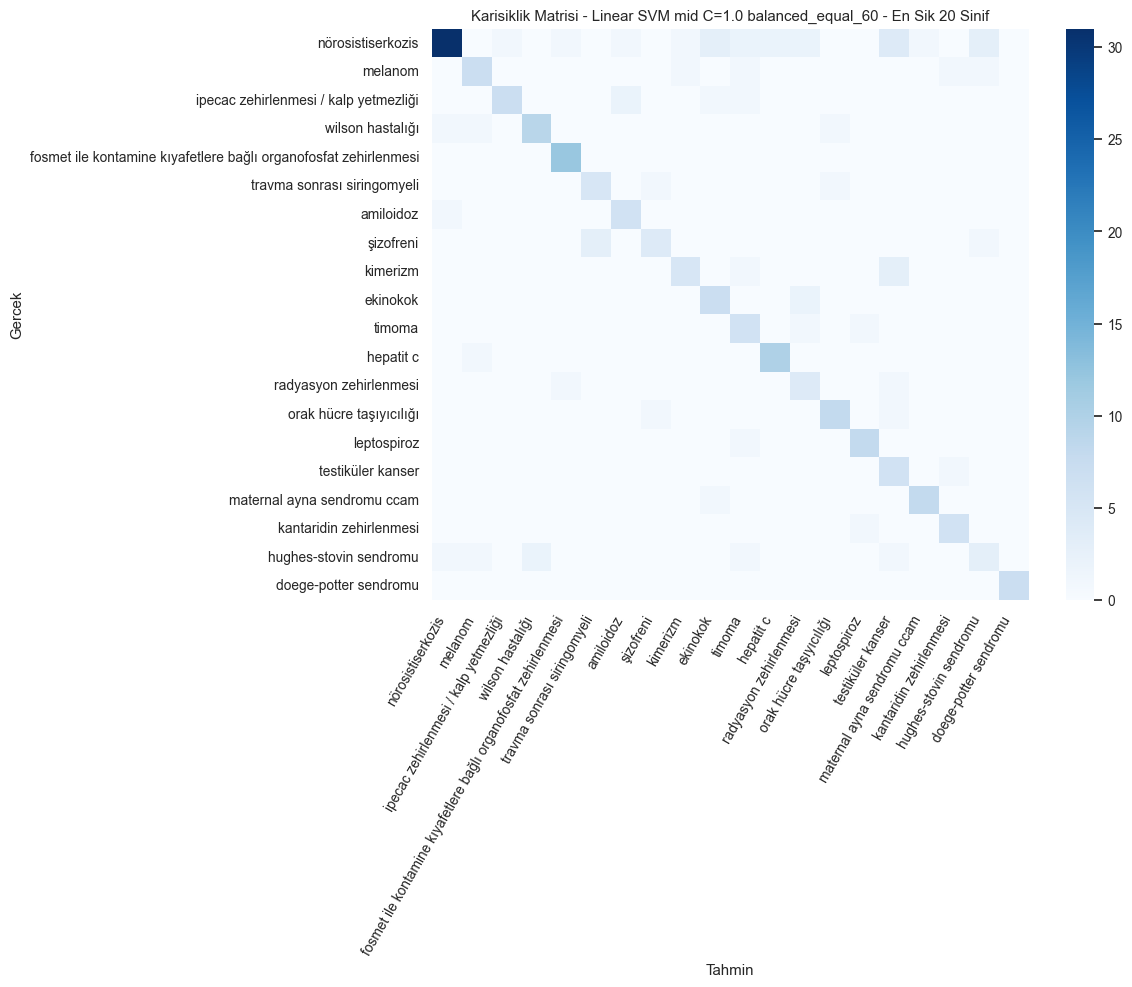

In [16]:
top_labels = y_test.value_counts().head(20).index.tolist()
cm = confusion_matrix(y_test, y_pred_best, labels=top_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=top_labels,
    yticklabels=top_labels,
)
plt.title(f"Karisiklik Matrisi - {best_model_name} - En Sik 20 Sinif")
plt.xlabel("Tahmin")
plt.ylabel("Gercek")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
error_df = df_model.loc[idx_test, [
    "season", "episode", "speaker", "text", "Symptom", "Test", "Drug", "Procedure", "Organ", "target"
]].copy()
error_df["prediction"] = y_pred_best
error_df["is_correct"] = error_df["target"].values == error_df["prediction"].values

print("Dogru tahmin orani:", round(error_df["is_correct"].mean(), 4))
print("Yanlis tahmin sayisi:", int((~error_df["is_correct"]).sum()))

display(error_df[~error_df["is_correct"]].head(20))

Dogru tahmin orani: 0.5368
Yanlis tahmin sayisi: 409


,season,episode,speaker,text,Symptom,Test,Drug,Procedure,Organ,target,prediction,is_correct
1302,2,19,Wilson,Grace'in kanser tümörlerinin görüntülerini aldım. Tümörler küçüldü.,tümör küçülmesi,,,,karaciğer,herpes ensefaliti,teratoma,False
31,1,1,Foreman,Kalbini yeniden çalıştırmak için elektrik şoku vermek zorunda kaldık.,,,,defibrilasyon,kalp,nörosistiserkozis,kolşisin zehirlenmesi,False
2955,5,18,Taub,Deri testi yapalım. Alerjik reaksiyon ya da paraziter enfeksiyon olabilir.,,Test,,,,karsinoid tümör apandis,testiküler kanser,False
1435,3,1,House,Bu MS değil; baş aşağı durmadan önce hiçbir semptomu yoktu.,,,,,,iskorbüt,subakut sklerozan panensefalit,False
4282,8,3,Adams,"Aritmi geri döndü, şu an Heparin alıyor ve stabil ancak bu onu inme veya emboli riskine sokabilir.",Aritmi,,Heparin,,,plummer hastalığı,intradural arteriyovenöz malformasyona bağlı omurilik basısı,False
178,1,4,Foreman,Oğlunuzu vankomisinden çıkarıyoruz. MRSA olduğunu düşünüyoruz.,,,vankomisin,,,ekovirus 11,spinal menenjiyom,False
4291,8,3,House,"Çarpıntı tıbbi bir durum, kanayan kalp ise aptalca bir durum.",Çarpıntı,,,,kalp,plummer hastalığı,melanom,False
1323,2,19,Chase,Radyasyonun gecikmiş etkisi olabilir. Bazen biraz zaman alır.,,,,radyasyon,,herpes ensefaliti,radyasyon zehirlenmesi,False
301,1,7,Chase,Geç evre Lyme hastalığı nöbetlere neden olabilir.,,,,,,afrika uyku hastalığı,kantaridin zehirlenmesi,False
4376,8,5,House,Bu yüzden onu geniş spektrumlu antibiyotiklere boğacağız.,,,antibiyotik,,,kawasaki hastalığı,plummer hastalığı,False


## 10. Modelin canliya alinmasi ve etik notu

Canliya alma icin sadece tek paket uretilir: `models/best_housemd_diagnosis_model.joblib`. Paket; egitilmis pipeline'i, sinif listesini, veri temizleme ozetini ve model metriklerini icerir.

Etik sinir: Bu calisma House M.D. repliklerinden uretilmis egitim/amaclidir. Cikti tibbi tani veya tedavi onerisi olarak kullanilmamalidir; gercek hasta verisiyle kullanilacaksa anonimlestirme, onay ve uzman kontrolu gerekir.


In [18]:
data_summary = {
    "raw_rows": int(raw_row_count),
    "blank_rows_removed": int(blank_row_count),
    "valid_rows_after_label_text_cleaning": int(len(df_clean)),
    "raw_valid_class_count_before_canonical_merge": int(before_valid_class_count),
    "class_count_after_canonical_merge": int(after_canonical_class_count),
    "rare_class_count_removed": int(rare_class_count),
    "rare_rows_removed": int(rare_row_count),
    "duplicate_rows_removed": int(duplicate_rows_removed),
    "model_rows_after_min_class_and_dedup": int(len(df_model)),
    "class_count": int(df_model["target"].nunique()),
    "min_class_count_used": int(MIN_CLASS_COUNT),
    "class_imbalance_ratio_before_train_balancing": float(round(imbalance_ratio, 4)),
    "required_balanced_train_class_size": int(BALANCED_TRAIN_CLASS_SIZE),
    "final_fit_min_class": int(fit_summaries[best_model_name]["fit_min_class"]),
    "final_fit_max_class": int(fit_summaries[best_model_name]["fit_max_class"]),
    "final_fit_balance_ratio": float(round(fit_summaries[best_model_name]["fit_max_class"] / fit_summaries[best_model_name]["fit_min_class"], 4)),
    "train_rows_before_balancing": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "target_column": TARGET_COLUMN,
    "selection_metric": SELECTION_METRIC,
    "selection_reason": selection_reason,
    "balancing_methods": ["balanced_equal_60", "balanced_equal_80"],
    "text_feature_columns": TEXT_FEATURE_COLUMNS,
    "meta_feature_columns": META_FEATURE_COLUMNS,
    "excluded_leakage_columns": LEAKAGE_COLUMNS,
    "ethics_note": "Educational House M.D. NLP model; not a clinical diagnostic or treatment tool.",
}

model_package = {
    "pipeline": best_model,
    "best_model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "min_class_count": MIN_CLASS_COUNT,
    "classes": sorted(df_model["target"].unique().tolist()),
    "label_synonym_map": LABEL_SYNONYM_MAP,
    "data_summary": data_summary,
    "class_summary": class_summary.to_dict(orient="records"),
    "merge_summary": merge_summary.to_dict(orient="records"),
    "cv_results": cv_results.to_dict(orient="records"),
    "test_results": test_results.to_dict(orient="records"),
    "classification_report": report_text,
    "saved_at": datetime.now().isoformat(timespec="seconds"),
}

MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(model_package, MODEL_PATH)

print("Model package ready:", MODEL_PATH.resolve())
print("Only one deployment artifact is written to keep the project structure clean.")
display(pd.DataFrame([data_summary]))

Model package ready: C:\Users\moham\Desktop\NLP_Project\models\best_housemd_diagnosis_model.joblib
Only one deployment artifact is written to keep the project structure clean.


,raw_rows,blank_rows_removed,valid_rows_after_label_text_cleaning,raw_valid_class_count_before_canonical_merge,class_count_after_canonical_merge,rare_class_count_removed,rare_rows_removed,duplicate_rows_removed,model_rows_after_min_class_and_dedup,class_count,...,train_rows_before_balancing,test_rows,target_column,selection_metric,selection_reason,balancing_methods,text_feature_columns,meta_feature_columns,excluded_leakage_columns,ethics_note
0,7282,0,5415,633,625,545,1001,0,4414,80,...,3531,883,correct_prediction,macro_f1,Final model is selected only from balanced_equal candidates because the project requires all labels to be equal or very close during training.,"[balanced_equal_60, balanced_equal_80]","[text, Symptom, Test, Drug, Procedure, Organ]","[speaker, Intent, diagnosis_stage, Emotion, Sarcasm]","[correct_prediction, model_prediction, season, episode]",Educational House M.D. NLP model; not a clinical diagnostic or treatment tool.


## 11. Yeni metin uzerinde tahmin ve BOT cevabi

Model tek bir tani dondurebilir; ancak daha duzgun bir BOT deneyimi icin ilk 5 aday da listelenir. Bu, modelin emin olmadigi durumlarda kullaniciya daha seffaf bir cevap verir.


In [19]:
def _scores_to_topk(model, model_text, top_k=5):
    classes = np.array(model.classes_)
    if hasattr(model, "decision_function"):
        scores = model.decision_function([model_text])
        scores = np.asarray(scores)
        if scores.ndim == 1:
            scores = scores.reshape(1, -1)
        row_scores = scores[0]
    elif hasattr(model, "predict_proba"):
        row_scores = model.predict_proba([model_text])[0]
    else:
        prediction = model.predict([model_text])[0]
        return pd.DataFrame([{"rank": 1, "prediction": prediction, "score": np.nan}])

    order = np.argsort(row_scores)[::-1][:top_k]
    return pd.DataFrame({
        "rank": np.arange(1, len(order) + 1),
        "prediction": classes[order],
        "score": row_scores[order],
    })


def predict_diagnosis(text, model_package=model_package, top_k=5):
    cleaned = normalize_text(text)
    return _scores_to_topk(model_package["pipeline"], cleaned, top_k=top_k)


def predict_diagnosis_from_fields(model_package=model_package, top_k=5, **fields):
    row = pd.Series(fields)
    model_text = build_model_text(row)
    return _scores_to_topk(model_package["pipeline"], model_text, top_k=top_k)


def bot_answer(text=None, model_package=model_package, top_k=3, **fields):
    if fields:
        field_payload = dict(fields)
        if text is not None:
            field_payload["text"] = text
        predictions = predict_diagnosis_from_fields(model_package=model_package, top_k=top_k, **field_payload)
    else:
        predictions = predict_diagnosis(text or "", model_package=model_package, top_k=top_k)

    first = predictions.iloc[0]
    alternatives = ", ".join(predictions["prediction"].astype(str).tolist()[1:])
    return {
        "answer": (
            f"Bu House M.D. veri seti modeline gore en olasi etiket: {first['prediction']}. "
            f"Alternatifler: {alternatives}. Bu cikti egitim amaclidir; klinik tani yerine gecmez."
        ),
        "top_predictions": predictions,
    }


free_text_examples = [
    "G\u00f6\u011f\u00fcs a\u011fr\u0131s\u0131, kalp yetmezli\u011fi ve nefes darl\u0131\u011f\u0131 bulgular\u0131 var.",
    "Karaci\u011fer enzimleri y\u00fcksek, hasta ila\u00e7 sonras\u0131 daha k\u00f6t\u00fc oldu.",
]

for example in free_text_examples:
    print("Free text:", example)
    display(predict_diagnosis(example, top_k=5))
    print("-" * 80)

structured_examples = [
    {
        "text": "Hasta n\u00f6bet ge\u00e7irdi, MR g\u00f6r\u00fcnt\u00fcs\u00fcnde beyinde lezyon var.",
        "Symptom": "n\u00f6bet",
        "Test": "MR",
        "Organ": "beyin",
        "Intent": "a\u00e7\u0131klama",
        "diagnosis_stage": "hipotez",
        "Emotion": "n\u00f6tr",
        "Sarcasm": "0",
    },
    {
        "text": "Kalp yetmezli\u011fi, nefes darl\u0131\u011f\u0131 ve ipecac \u015f\u00fcphesi var.",
        "Symptom": "nefes darl\u0131\u011f\u0131",
        "Drug": "ipecac",
        "Organ": "kalp",
        "Intent": "a\u00e7\u0131klama",
        "diagnosis_stage": "de\u011ferlendirme",
        "Emotion": "n\u00f6tr",
        "Sarcasm": "0",
    },
]

for fields in structured_examples:
    print("Structured fields:", fields["text"])
    display(predict_diagnosis_from_fields(**fields, top_k=5))
    print("-" * 80)

bot_demo = bot_answer(**structured_examples[0])
print(bot_demo["answer"])


Free text: Göğüs ağrısı, kalp yetmezliği ve nefes darlığı bulguları var.


,rank,prediction,score
0,1,ipecac zehirlenmesi / kalp yetmezliği,-0.296937
1,2,kobalt zehirlenmesi,-0.674357
2,3,henoch-schönlein purpura,-0.719948
3,4,meme kanseri,-0.764941
4,5,fmf,-0.773345


--------------------------------------------------------------------------------
Free text: Karaciğer enzimleri yüksek, hasta ilaç sonrası daha kötü oldu.


,rank,prediction,score
0,1,hepatit c ve ornitin transkarbamilaz eksikliği,-0.325064
1,2,hiperviskozite sendromu,-0.664330
2,3,radyasyon zehirlenmesi,-0.726074
3,4,nörosistiserkozis,-0.759363
4,5,travma sonrası siringomyeli,-0.766961


--------------------------------------------------------------------------------
Structured fields: Hasta nöbet geçirdi, MR görüntüsünde beyinde lezyon var.


,rank,prediction,score
0,1,nörosistiserkozis,-0.509420
1,2,herpes ensefaliti,-0.551504
2,3,ekovirus 11,-0.699553
3,4,travma sonrası siringomyeli,-0.756506
4,5,subakut sklerozan panensefalit,-0.802763


--------------------------------------------------------------------------------
Structured fields: Kalp yetmezliği, nefes darlığı ve ipecac şüphesi var.


,rank,prediction,score
0,1,ipecac zehirlenmesi / kalp yetmezliği,0.768589
1,2,amiloidoz,-0.527936
2,3,kobalt zehirlenmesi,-0.734725
3,4,suçiçeği,-0.789047
4,5,fmf,-0.817033


--------------------------------------------------------------------------------
Bu House M.D. veri seti modeline gore en olasi etiket: nörosistiserkozis. Alternatifler: herpes ensefaliti, ekovirus 11. Bu cikti egitim amaclidir; klinik tani yerine gecmez.


## Sonuc ve notlar

Bu notebook hocanin bekledigi bes asamayi izler:

1. House M.D. veri seti okunur, tamamen bos satirlar silinir, hedef/metin kalitesi raporlanir.
2. On isleme ve ozellik seciminde metin, tibbi varliklar ve meta alanlar temizlenerek TF-IDF word + character n-gram ozellikleri uretilir.
3. Modelleme asamasinda baseline, Naive Bayes ve Linear SVM adaylari capraz dogrulama/test ile karsilastirilir.
4. Canliya alma icin tek bir `joblib` model paketi `models` klasorune yazilir; etik not model paketine ve BOT cevabina eklenir.
5. Yazili rapor ve sozlu sunum icin veri temizleme, dengeleme, metrik ve etik ozetleri notebook icinde tablo olarak hazirdir.

En kritik sart olan etiket dengesi final modelde saglanir: final adaylar sadece `balanced_equal_*` stratejilerinden secilir ve egitimde her sinif ayni sayida ornek gorur. Test seti ise gercek dagilimda birakilir; boylece performans raporu daha durustur.
